In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
# Load the diabetes dataset
diabetes_bunch = load_diabetes()
diabetes = pd.DataFrame(diabetes_bunch.data, columns=diabetes_bunch.feature_names)
diabetes['target'] = diabetes_bunch.target
diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
X=diabetes.drop('target', axis=1)
y=diabetes['target']

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [4]:
lr.fit(X_train, y_train)
print("Linear Regression Coefficients:", lr.coef_)
print("Linear Regression Intercept:", lr.intercept_)

Linear Regression Coefficients: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
Linear Regression Intercept: 151.34560453985995


In [5]:
y_pred_lr = lr.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R^2:", r2_score(y_test, y_pred_lr))

Linear Regression MSE: 2900.1936284934804
Linear Regression R^2: 0.4526027629719196


In [6]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=100.0)
ridge.fit(X_train, y_train)
print("Ridge Regression Coefficients:", ridge.coef_)
print("Ridge Regression Intercept:", ridge.intercept_)

Ridge Regression Coefficients: [ 2.41457328  0.03631503  7.68959184  5.78651722  2.48854891  1.90201877
 -4.83251122  5.39725175  7.07265406  5.0306732 ]
Ridge Regression Intercept: 153.69087475006762


In [7]:
y_pred_ridge = ridge.predict(X_test)
print("Ridge Regression MSE:", mean_squared_error(y_test, y_pred_ridge))
print("Ridge Regression R^2:", r2_score(y_test, y_pred_ridge))

Ridge Regression MSE: 5233.663686578425
Ridge Regression R^2: 0.012171803489062438


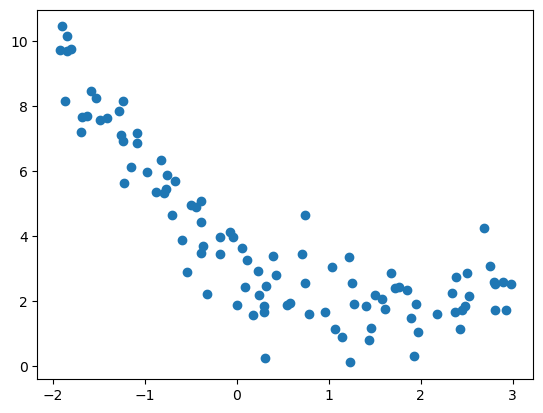

In [8]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

d:\CondaEnvs\placement_env\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.86503e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


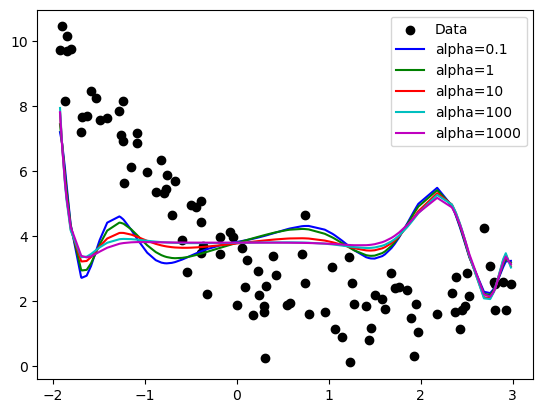

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0.1, 1, 10, 100, 1000]
colors = ['b', 'g', 'r', 'c', 'm']
plt.scatter(x1, x2, color='k', label='Data')
for alpha, color in zip(alphas, colors):
    x1_sorted = np.sort(x1, axis=0)
    x2_pred = get_preds_ridge(x1_sorted, x2, alpha)
    plt.plot(x1_sorted, x2_pred, color=color, label=f'alpha={alpha}')
plt.legend()
plt.show()